Isabella Esquivel
April 30, 2026
University of Miami
College of Engineering
Coral Gables, FL 33146

# Heart Failure: Tree-Based Predictors of Mortality and Ejection Fraction


# 1. Introduction


#### Background

According to Mayo Clinic, heart failure occurs when the heart muscle does not pump blood as it should, causing blood to back up. This may lead to fluid building in the lungs, causing shortness of breath. The Heart Failure Society of America reported that heart failure was a contributing cause in 425,147 deaths in the United States in 2022, making up 45% of cardiovascular deaths.

Medical records of patients who have undergone heart failure could be used to analyze and identify patterns in patient survival. These clinical factors include ejection fraction, serum creatinine, and serum sodium as well as other demographic factors, such as age and gender. Understanding how these clinical indicators could **predict the event of death** following heart failure is essential to improve disease management.

##### Prior Studies

Chicco and Jurman(2020) previously demonstrated that the strongest predictors of mortality among heart failure patients were serum creatinine and ejection fraction by using machine learning classification techniques. Additionally, in 2017, Ahmad and colleagues conducted a survival analysis, and found that age, renal dysfunction(having serum creatinine greater than
its normal level 1.5), high blood pressure, high levels of anaemia, and lower values of ejection fraction as the most significant risk factors for death following heart failure.

##### Relevant Previous Analysis Results

Using the Heart Failure dataset, four classification techniques were evaluated in order to predict patient mortality outcomes. The full logistic regression model achieved a test accuracy of approximately 78.8%. When the model was reduced to include only ejection fraction and serum creatinine, test accuracy improved to approximately 85.9%.

Linear Discriminant Analysis (LDA) achieved a similar test accuracy of approximately 84.8%. Quadratic Discriminant Analysis (QDA) produced a higher test accuracy of approximately 89.9%, and the Naive Bayes classifier achieved the same test accuracy of approximately 89.9%. Overall, QDA and Naive Bayes demonstrated the strongest predictive performance among the models considered.

#### Study Objective

The objective of this study is to implement and evaluate tree-based machine learning on the Heart Failure Clinical Records dataset containing clinical and demographic data of 299 patients. Two prediction tasks are explored: the classification of patient mortality (DEATH_EVENT) and the regression prediction of serum creatinine levels. Serum creatinine is selected as studies have previously concluded that it is a strong predictor of mortality.

For classification, one classification tree is fit, pruned by cross-validation to select the best pruned tree, and used for prediction. For regression, one regression tree is fit and pruned, and more advanced methods such as bagging, random forests, boosting, and BART (Bayesian Additive Regression Trees) are used, all of which combine multiple trees to improve prediction. The goal is to identify clinical factors most strongly associated with heart failure outcomes.

# 2. Data and Methods

 ### Dataset Description

The dataset used consists of 299 patients with heart failure. 13 clinical and demographic variables were collected from each patient, including age, sex, anaemia status, diabetes status, high blood pressure, smoking status, serum creatinine, serum sodium, creatinine phosphoinase(CPK), platelet count, follow-up time, ejection fraction, and death event (see table 1 for descriptions).

Table 1

In [ ]:
knitr::kable(variable_table, caption = "Table 1. Description of Clinical Variables Included in the Heart Failure Dataset")




Table: Table 1. Description of Clinical Variables Included in the Heart Failure Dataset

|Variable                 |Description                                           |
|:------------------------|:-----------------------------------------------------|
|age                      |Age of the patient (years)                            |
|anaemia                  |Decrease of red blood cells or hemoglobin (boolean)   |
|creatinine_phosphokinase |Level of CPK enzyme in blood (mcg/L)                  |
|diabetes                 |Presence of diabetes (boolean)                        |
|ejection_fraction        |Percentage of blood leaving heart at each contraction |
|high_blood_pressure      |Presence of hypertension (boolean)                    |
|platelets                |Platelets in blood (kiloplatelets/mL)                 |
|sex                      |Sex (binary: 0 = female, 1 = male)                    |
|serum_creatinine         |Serum creatinine level (mg/dL)                      

In [ ]:
HeartFailure <- read.csv("HeartFailure.csv")

In [ ]:
head(HeartFailure)
names(HeartFailure)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,Death,Death.1
,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>
1,75,0,582,0,20,1,265000,1.9,130,1,0,4,1,Yes,Yes
2,55,0,7861,0,38,0,263358,1.1,136,1,0,6,1,Yes,Yes
3,65,0,146,0,20,0,162000,1.3,129,1,1,7,1,Yes,Yes
4,50,1,111,0,20,0,210000,1.9,137,1,0,7,1,Yes,Yes
5,65,1,160,1,20,0,327000,2.7,116,0,0,8,1,Yes,Yes
6,90,1,47,0,40,1,204000,2.1,132,1,1,8,1,Yes,Yes


[1] "age"                      "anaemia"                 
 [3] "creatinine_phosphokinase" "diabetes"                
 [5] "ejection_fraction"        "high_blood_pressure"     
 [7] "platelets"                "serum_creatinine"        
 [9] "serum_sodium"             "sex"                     
[11] "smoking"                  "time"                    
[13] "DEATH_EVENT"              "Death"                   
[15] "Death.1"

Summary of each clinical and demographic factor in the Heart Failure Dataset:

In [ ]:
summary(HeartFailure)

      age           anaemia       creatinine_phosphokinase    diabetes     
 Min.   :40.00   Min.   :0.0000   Min.   :  23.0           Min.   :0.0000  
 1st Qu.:51.00   1st Qu.:0.0000   1st Qu.: 116.5           1st Qu.:0.0000  
 Median :60.00   Median :0.0000   Median : 250.0           Median :0.0000  
 Mean   :60.83   Mean   :0.4314   Mean   : 581.8           Mean   :0.4181  
 3rd Qu.:70.00   3rd Qu.:1.0000   3rd Qu.: 582.0           3rd Qu.:1.0000  
 Max.   :95.00   Max.   :1.0000   Max.   :7861.0           Max.   :1.0000  
 ejection_fraction high_blood_pressure   platelets      serum_creatinine
 Min.   :14.00     Min.   :0.0000      Min.   : 25100   Min.   :0.500   
 1st Qu.:30.00     1st Qu.:0.0000      1st Qu.:212500   1st Qu.:0.900   
 Median :38.00     Median :0.0000      Median :262000   Median :1.100   
 Mean   :38.08     Mean   :0.3512      Mean   :263358   Mean   :1.394   
 3rd Qu.:45.00     3rd Qu.:1.0000      3rd Qu.:303500   3rd Qu.:1.400   
 Max.   :80.00     Max.   :1.0

In [ ]:
attach(HeartFailure)

#### Packages

In [ ]:
install.packages('tree')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(tree)

## 3. Model

###  Fitting Classification Trees

First, classification trees are used to analyze the `Heart Failure` data set.
In this data, `Death_Event` is already a binary variable, which takes on a value of `1` if the patient passed away, or `0` if the patient survived.

##### Histogram of Death_Event

Before we fit a classification tree, a histogram is made to view the dsitribution of patient outcomes in this dataset. There are 299 patients in this data set, in which 203 patients survived, `67.89%`, and 96 patients died, `32.11%`.

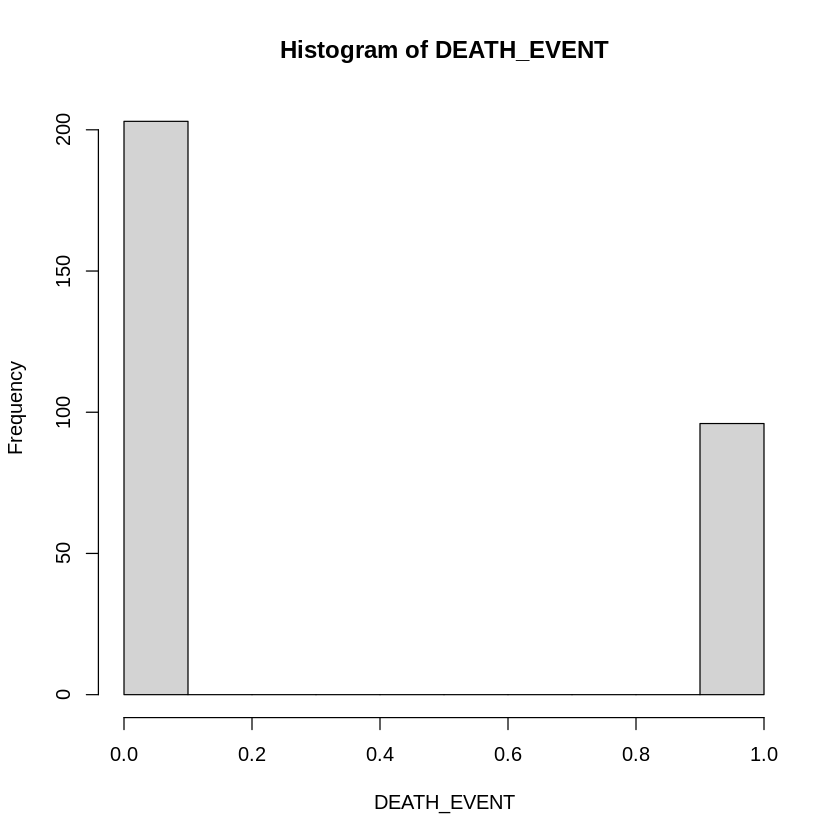

In [ ]:
hist(DEATH_EVENT)

##### Classification Tree using Yes or No Death Metric

The binary variable in ` Death_Event` is recoded to Yes and No using the `ifelse()` and `data.frame()` function to add this to the data set.

In [ ]:
Death <- factor(ifelse(DEATH_EVENT == 1, "Yes", "No"))

In [ ]:
HeartFailure <- data.frame(HeartFailure, Death)

Then, the `tree()` function is used to fit a classification tree in order to predict `Death` using all variables but `Death_Event` and `time`.

In [ ]:
tree.HeartFailure <- tree(Death ~ . - DEATH_EVENT- time, HeartFailure)

The `summary()` function lists the variables that are used as internal nodes in the tree, the number of terminal nodes, and the (training) error rate.

In [ ]:
summary(tree.HeartFailure)


Classification tree:
tree(formula = Death ~ . - DEATH_EVENT - time, data = HeartFailure)
Variables actually used in tree construction:
[1] "serum_creatinine"         "ejection_fraction"       
[3] "serum_sodium"             "age"                     
[5] "creatinine_phosphokinase"
Number of terminal nodes:  11 
Residual mean deviance:  0.8297 = 238.9 / 288 
Misclassification error rate: 0.1773 = 53 / 299 

The training error rate is  $17.7\%$ or training accuracy is $82.3\%$.

For classification trees, the deviance reported in the output of `summary()` is
given by

$$-2 \sum_m \sum_k n_{mk} \log \hat{p}_{mk}$$,

 where $n_{mk}$ is the number of observations in the $m$th terminal node that belong to the $k$th class.

A small deviance indicates a tree that provides a good fit to the (training) data. The *residual mean deviance* reported is simply the deviance divided by $n-|{T}_0|$, which in this case is $299-11=288$.

##### Plotted Classification Tree
The `plot()` function is used to display the tree structure, and the `text()` function to display the node labels.

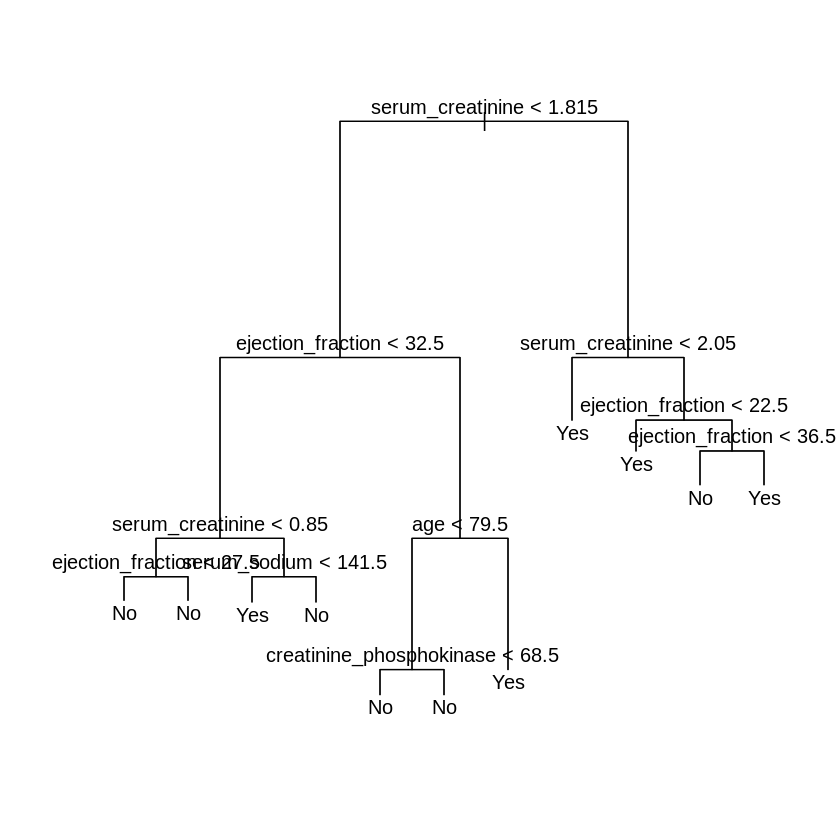

In [ ]:
plot(tree.HeartFailure)
text(tree.HeartFailure, pretty = 0)

The most important indicator of `Death` appears to be `serum_creatinine`, since the first branch differentiates higher values than 1.815. Serum creatinine represents kidney dysfunction, and a higher value seems to pose a higher mortality risk. Then this variable appears two more times in the tree. `Ejection_fraction`, which represents heart function, also appears three times. This confirms earlier results that these two clinical values are mostly the strongest predictors of death. `Age`, `serum_sodium`, and `creatine_phosphokinase` appear further down most likely to refine predictions. However, these are clearly weaker predictors of mortality.

#### Tree Object Properties: Branches, Split Criterion, and More

Next, name of the tree object is typed, since `R` prints output corresponding to each branch of the tree. `R` displays the split criterion , the number of observations in that branch, the deviance,  the overall prediction for the branch (`Yes` or `No`),  and the fraction of observations in that branch that take on values of `Yes` and `No`. Branches that lead to terminal nodes are indicated using asterisks.

In [ ]:
tree.HeartFailure

node), split, n, deviance, yval, (yprob)
      * denotes terminal node

 1) root 299 375.300 No ( 0.6789 0.3211 )  
   2) serum_creatinine < 1.815 251 278.400 No ( 0.7570 0.2430 )  
     4) ejection_fraction < 32.5 71  98.410 No ( 0.5070 0.4930 )  
       8) serum_creatinine < 0.85 12  10.810 No ( 0.8333 0.1667 )  
        16) ejection_fraction < 27.5 5   6.730 No ( 0.6000 0.4000 ) *
        17) ejection_fraction > 27.5 7   0.000 No ( 1.0000 0.0000 ) *
       9) serum_creatinine > 0.85 59  80.960 Yes ( 0.4407 0.5593 )  
        18) serum_sodium < 141.5 53  71.170 Yes ( 0.3962 0.6038 ) *
        19) serum_sodium > 141.5 6   5.407 No ( 0.8333 0.1667 ) *
     5) ejection_fraction > 32.5 180 148.700 No ( 0.8556 0.1444 )  
      10) age < 79.5 167 109.900 No ( 0.8982 0.1018 )  
        20) creatinine_phosphokinase < 68.5 19   0.000 No ( 1.0000 0.0000 ) *
        21) creatinine_phosphokinase > 68.5 148 105.500 No ( 0.8851 0.1149 ) *
      11) age > 79.5 13  16.050 Yes ( 0.3077 0.6923 ) *
   

Since there are 299 patients in this data set, in which 203 patients survived, $67.89\%$, and 96 patients died, $32.11\%$, the default prediction is $No$.

Then the first split is for `serum_creatinine` where patients with levels higher than $1.815$ were projected to have a $72.9\%$ chance of mortality, and patients with less than $1.815$ were estimated to have a $75.7\%$ chance of staying alive. Moreover, a subsequent node split individuals with `serum_creatinine` levels higher than $2.05$, and showed that all $14$ of those patients died. Furthermore, when `ejection fraction` was under $22.5$, the death rate was also $100\%$.

Notably, node $17$ reveals an interesting interaction between cardiac
and kidney function. The $7$ patients in this node had a relatively low
`ejection_fraction` between $27.5\%$ and $32.5\%$, which represents poor heart function. However, their `serum_creatinine` was below $0.85$, reflecting
strong kidney function, and all $7$ patients survived, producing a $100\%$
survival rate. This could mean that healthy kidney function may compensate
for reduced cardiac function.

Furthermore, age reveals itself to be important at the extremes as a secondary filter. For example, if ejection fraction is above $32.5$, AND the patient is over $79.5$, the model predicts death with a $69\%$ rate, while younger patients only have a $10\%$ chance. This reveals that while cardiac function is the dominant
predictor, advanced age significantly increases mortality risk even when
ejection fraction appears less risky.

Additionally, `serum_sodium` acts as a protective factor at node $18$
and $19$, since patients with higher levels were more likely to survive. Those with levels above $141.5$ had only a $16.7\%$ death
rate, compared to $60.4\%$ for those below $141.5$.

Interestingly, the tree only used $6$ of the $11$ predictors available, with `anaemia`, `diabetes`, `high_blood_pressure`, `platelets`, `sex` and `smoking` not contributing enough to warrant a split, which is consistent with findings from prior research .

##### Evaluating Classification Tree Performance on Test Data

In order to properly evaluate the performance of a classification tree
on the `Heart Failure` data, the test error must be estimated rather than simply
computing the training error. To do this, the observations were splt into a
training set of $150$ patients and a test set of $149$. Then, the tree was built using the training set,
and its performance was evaluated on the test data.

The `predict()`
function was used to generate the predictions. In the case of a classification
tree, the argument `type = "class"` instructs `R` to return the
actual class prediction.


In [ ]:
set.seed(2)
train <- sample(1:nrow(HeartFailure), 150)
HeartFailure.test <- HeartFailure[-train, ]
Death.test <- Death[-train]
tree.HeartFailure <- tree(Death ~ . - DEATH_EVENT- time, HeartFailure,
    subset = train)
tree.pred <- predict(tree.HeartFailure, HeartFailure.test,
    type = "class")
table(tree.pred, Death.test)
(24 + 74) / 149

         Death.test
tree.pred No Yes
      No  79  23
      Yes 23  24

[1] 0.6577181

The obtained confusion matrix shows that the model correctly predicted $79$ survivors and $24$ deaths, but misclassified $23$ deaths as survival and $23$ survivors as death. This method correctly predicts about $65.7\%$ of patients in the test data set.

This accuracy is notably lower than the classification methods evaluated
in previous studies, where logistic regression achieved $78.8\%$, LDA
achieved $84.8\%$, and both QDA and Naive Bayes achieved $89.9\%$. The
relatively poor performance of the single classification tree could mean
that it may be overfitting the training data. More advanced tree-based methods such as pruning, bagging, random
forests, and boosting, will be used in the sections to follow to explore this.

##### Plotted Test Classification Tree

The unpruned classification tree fitted on the training set of $150$
patients is notably complex, with overlapping labels and deeply nested
splits involving variables such as `anaemia`, `diabetes`, and `platelets`,
which were consistently identified as weak predictors in previous analyses.

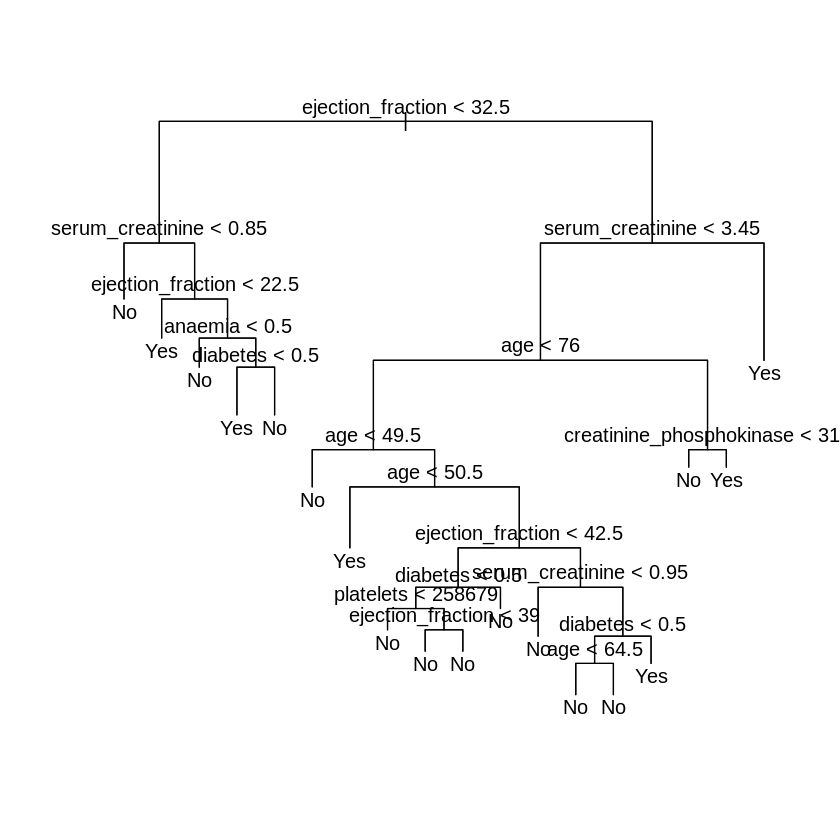

In [ ]:
plot(tree.HeartFailure)
text(tree.HeartFailure, pretty = 0)

##### Pruning the Tree: Removing Unnecessary Splits


Next, it is considered whether pruning the tree might lead to improved predictive performance on Heart Failure patient outcomes.
The function `cv.tree()` performs cross-validation in order to  determine the optimal level of tree complexity; cost complexity pruning is used in order to select a sequence of trees for consideration.

The argument `FUN = prune.misclass` is used in order to indicate that we want the classification error rate, in this case the misclassfication of patient death, to guide the cross-validation and pruning process, rather than the default for the `cv.tree()` function, which is deviance.

The `cv.tree()` function reports the number of terminal nodes of each tree considered (`size`) as well as the corresponding error rate and the value of the cost-complexity parameter used.

In [ ]:
set.seed(7)
cv.HeartFailure <- cv.tree(tree.HeartFailure, FUN = prune.misclass)
names(cv.HeartFailure)
cv.HeartFailure

[1] "size"   "dev"    "k"      "method"

$size
[1] 18 13 10  8  5  4  2  1

$dev
[1] 42 42 40 38 35 44 49 53

$k
[1]      -Inf 0.0000000 0.3333333 0.5000000 1.0000000 3.0000000 5.0000000
[8] 7.0000000

$method
[1] "misclass"

attr(,"class")
[1] "prune"         "tree.sequence"

The results indicate a clear trend: as the tree was progressively trimmed, classification performance consistently improved. The misclassification count decreased steadily from $42$ errors at $18$ nodes, down to a minimum of $35$ errors at $5$ terminal nodes.

However, trimming beyond $5$ nodes caused performance to worsen again, with errors rising to $44$, $49$, and $53$ as the tree was reduced to 4, 2, and 1 nodes respectively. This confirms that 5 terminal nodes represents the optimal balance when classifying `Death` among heart failure patients, and was therefore selected for pruning.

##### Graph of Trimmed Classification Trees

 We plot the  error rate as a function of both `size` and
`k`. The left plot shows that as the tree size decreases from
$18$ nodes, the misclassification error drops steadily, reaching its minimum of $35$ errors at $5$ terminal nodes, before rising again as the tree becomes too simple.

The right plot tells the same story from the opposite direction, as the complexity penalty $k$ increases, the model is forced into simpler trees, and errors eventually climb once the tree is pruned too much.

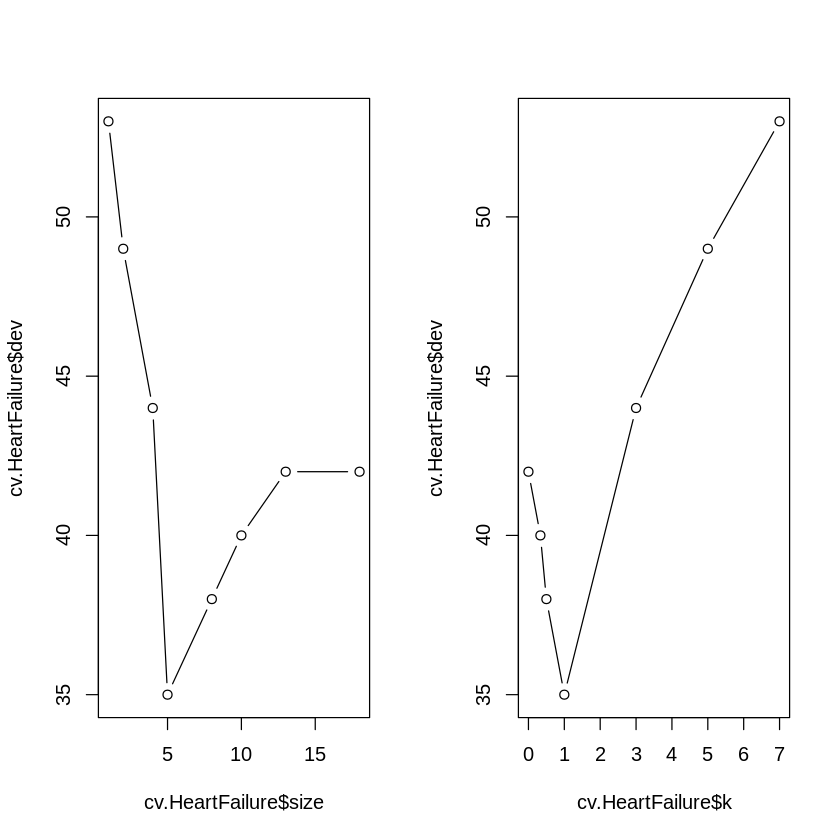

In [ ]:
par(mfrow = c(1, 2))
plot(cv.HeartFailure$size, cv.HeartFailure$dev, type = "b")
plot(cv.HeartFailure$k, cv.HeartFailure$dev, type = "b")

##### Pruned Five-Node Classification Tree

The  `prune.misclass()`  function is used in order to prune the tree to obtain the five-node tree. The resulting pruned tree is considerably simpler and more interpretable than the original $18$-node tree, relying on only three variables: `ejection_fraction`, `serum_creatinine`, and `age`. This is consistent with previous analyses run on the dataset.

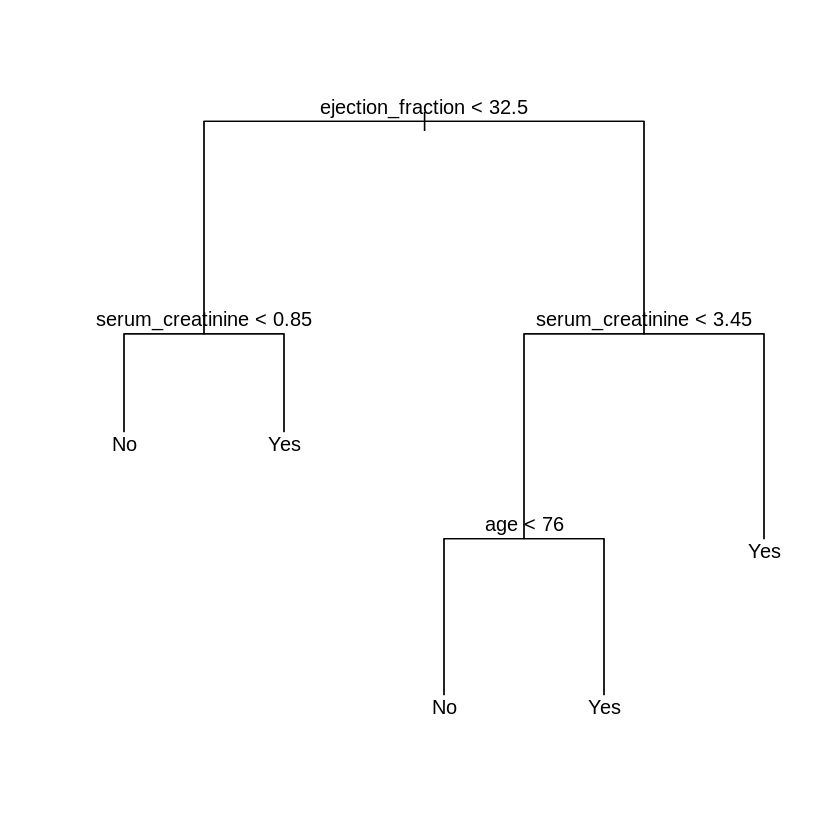

In [ ]:
prune.HeartFailure <- prune.misclass(tree.HeartFailure, best = 5)
plot(prune.HeartFailure)
text(prune.HeartFailure, pretty = 0)

The root split is done on `ejection_fraction` < 32.5 which means this is the single most important variable in predicting whether the heart failure patient will survive. Patients with low `ejection_fraction` are then further split based on `serum_creatinine` < 0.85 while patients with higher ejection fraction are evaluated using `serum_creatinine` < 3.45 and then `age` < 76.

This is in line with the current medical knowledge that `ejection fraction` and `serum creatinine` are well-known clinical predictors of outcome in heart failure patients and `age` is a known risk factor for mortality as mentioned above.

#####Pruned Tree Results

The pruned tree was then evaluated on the test set of 150 patients by applying the `predict()` function.

In [ ]:
tree.pred <- predict(prune.HeartFailure, HeartFailure.test,
    type = "class")
table(tree.pred, Death.test)
(73 + 37) / 150

         Death.test
tree.pred No Yes
      No  73  10
      Yes 29  37

[1] 0.7333333

 The confusion matrix shows that the model correctly classified $73$ patients who survived and $37$ patients who died, yielding an overall accuracy of $73.3\%$. However, the model misclassified $10$ survivors as having died and $29$ patients who actually died as survivors.

 If the value of `best` is increased, a larger pruned tree with lower classification accuracy is obtained. For example, by increasing to 14 nodes, we reduced the accuracy to $68\%$.

         Death.test
tree.pred No Yes
      No  80  24
      Yes 22  23

[1] 0.6866667

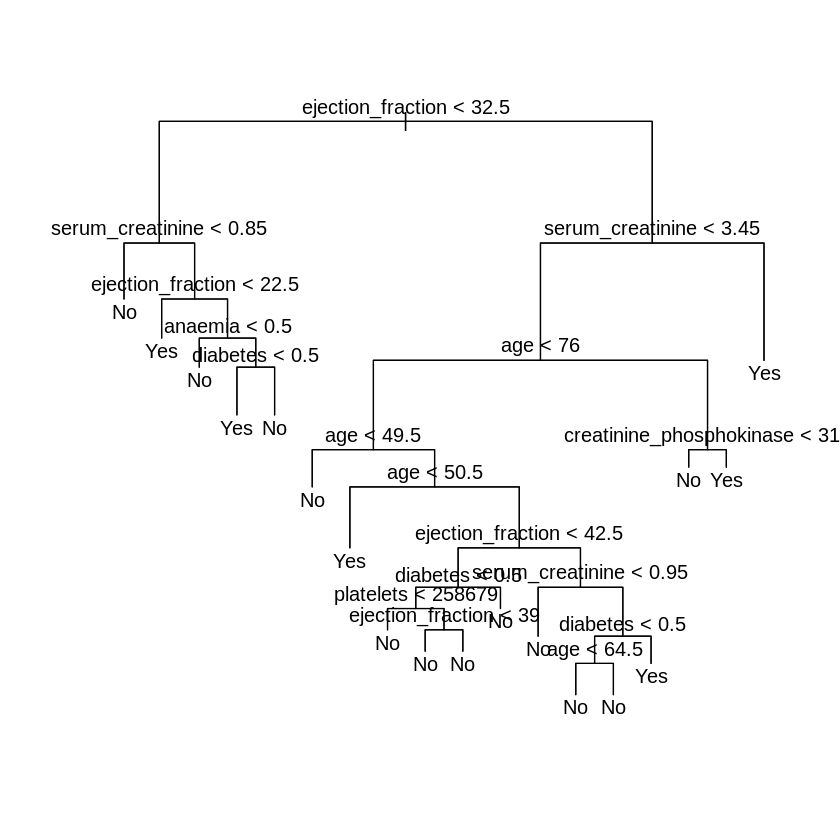

In [ ]:
prune.HeartFailure <- prune.misclass(tree.HeartFailure, best = 14)
plot(prune.HeartFailure)
text(prune.HeartFailure, pretty = 0)
tree.pred <- predict(prune.HeartFailure, HeartFailure.test,
    type = "class")
table(tree.pred, Death.test)
(80 + 23) / 150

### Fitting Regression Trees

Here we fit a regression tree to the `Heart Failure`  data set. While `ejection_fraction` was the dominant predictor in the training set classification tree, `serum_creatinine `was selected as the response variable for the regression tree analysis, as it was identified as the strongest predictor of mortality in the full 299-patient dataset and has been less explored in previous analyses.

First, we create a training set made up of half the data, and fit the tree to the training data, which is the other half of the data.

In [ ]:
set.seed(1)
train <- sample(1:nrow(HeartFailure), nrow(HeartFailure) / 2)
tree.HeartFailure <- tree(serum_creatinine ~ . - DEATH_EVENT - time-Death, HeartFailure, subset = train)
summary(tree.HeartFailure)


Regression tree:
tree(formula = serum_creatinine ~ . - DEATH_EVENT - time - Death, 
    data = HeartFailure, subset = train)
Variables actually used in tree construction:
[1] "platelets"                "creatinine_phosphokinase"
[3] "serum_sodium"             "ejection_fraction"       
[5] "age"                     
Number of terminal nodes:  7 
Residual mean deviance:  0.8655 = 122.9 / 142 
Distribution of residuals:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-2.41400 -0.33470 -0.07833  0.00000  0.13000  5.38600 

The summary output reveals that out of all available patient characteristics, the tree used only $5$ variables to predict `serum_creatinine`: `platelets`, `creatinine_phosphokinase`, `serum_sodium`, `ejection_fraction`, and `age`. The tree contains $7$ terminal nodes. The residual mean deviance of $0.8655$ represents the average squared error across the $142$ training observations.

##### Plotted Serum Creatinine Regression Tree

The root split is on `platelets` < $157500$, making it the most important variable in predicting `serum_creatinine` levels.


One the left side, patients with lower `platelet` counts are split by `creatinine_phosphokinase`. Those with lower `creatinine_phosphokinase` (< $567$.5) are predicted to have the highest `serum_creatinine` in the entire tree at $3.614$, while those with higher `creatinine_phosphokinase` are predicted at $1.270$.


On the right side, patients with higher `platelet` counts are first split by `serum_sodium`. Those with high` serum_sodium` (>= $143.5$) are predicted at $2.343$. Those with lower `serum_sodium` are then split by `ejection_fraction`. Patients with low `ejection_fraction` (< $27.5$) are further split by `creatinine_phosphokinase`, predicting $2.726$ for those below $120$ and $1.451$ for those above. Patients with higher `ejection_fraction` are split by `age`, predicting $1.078$ for those under $74$ and $1.515$ for those $74$ and older.

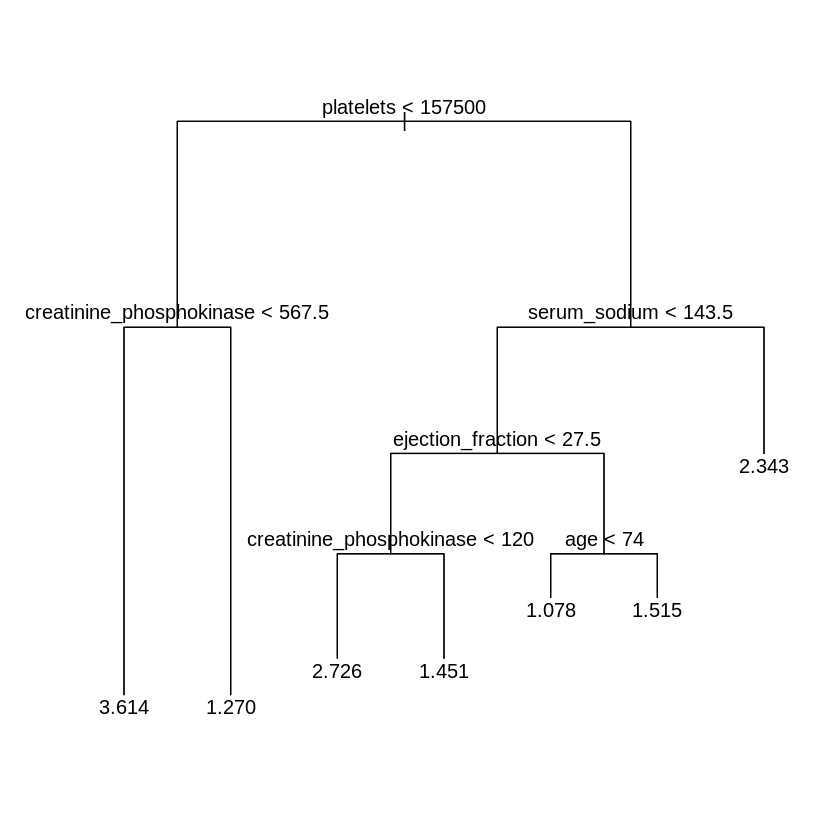

In [ ]:
plot(tree.HeartFailure)
text(tree.HeartFailure, pretty = 0)

Next, the `cv.tree()` function will be used to see whether pruning the tree will improve model performance in predicting `serum_creatinine`.

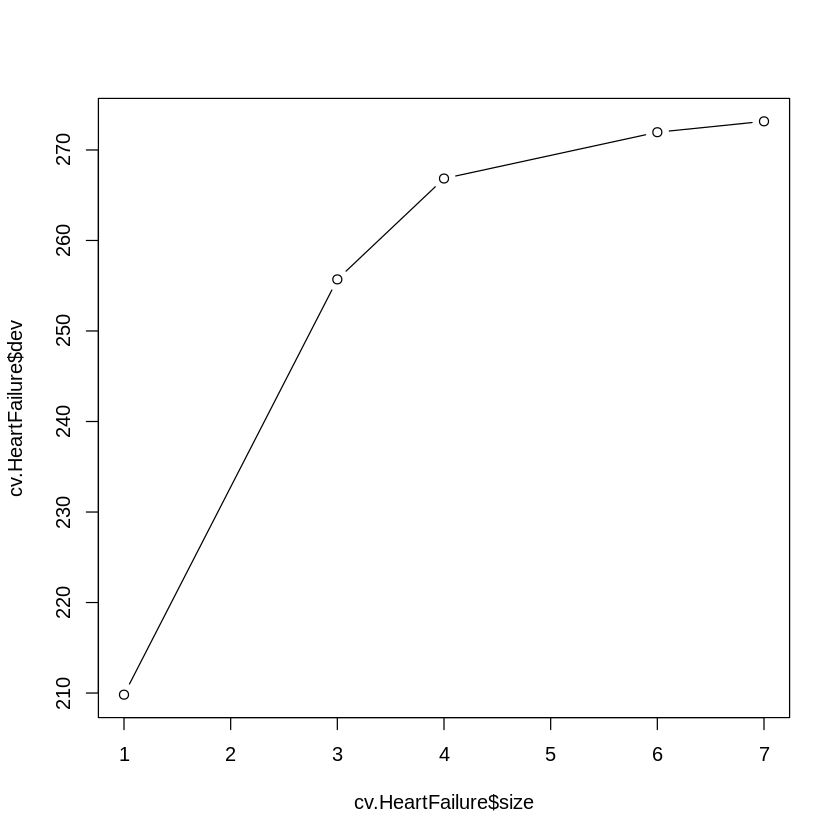

In [ ]:
cv.HeartFailure <- cv.tree(tree.HeartFailure)
plot(cv.HeartFailure$size, cv.HeartFailure$dev, type = "b")

Cross-validation shows that pruning the regression tree does improve the performance of the tree to predict `serum_creatinine` as the error is lowest at just $1$ terminal node and increases with every added split. This shows that the other characteristics of the patients do not have a strong enough relationship with `serum_creatinine`.

Although cross-validation showed that the simplest tree performs best, a tree with $2$ terminal nodes was selected in order to produce a meaningful tree structure for analysis.

The pruned tree retains only the two most important splits: `platelets` < $157500$ as the root split, and `creatinine_phosphokinase` < $567.5$ on the left side.

Patients with higher `platelet` counts are predicted a serum_creatinine of $1.318$, while those with lower `platelets` are further split by `creatinine_phosphokinase`, predicting $3.614$ for those below $567.5$ and $1.270$ for those above.

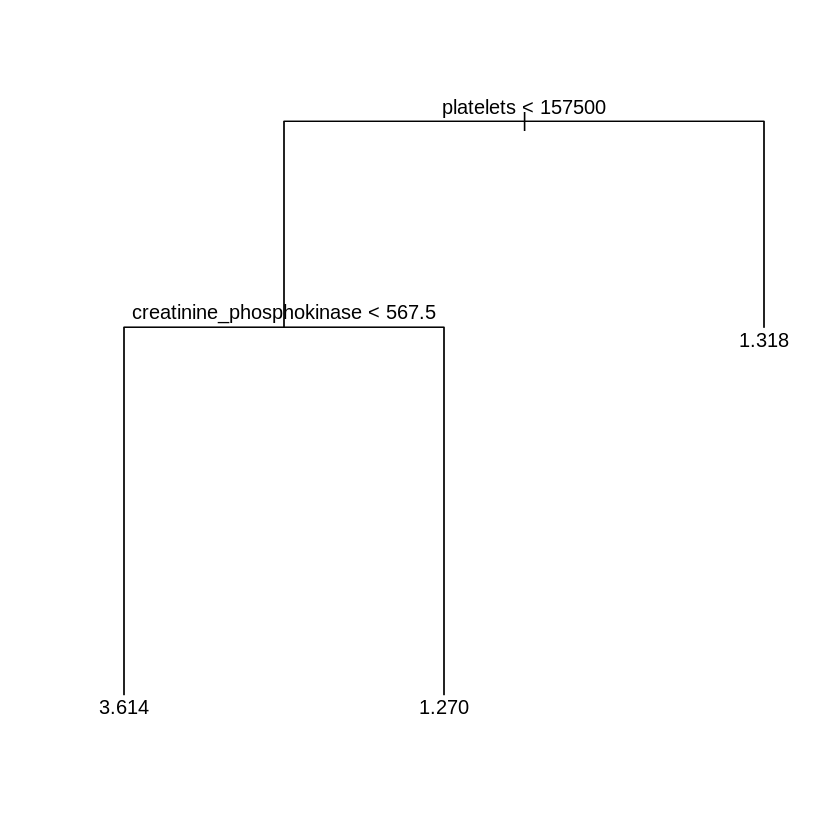

In [ ]:
prune.HeartFailure <- prune.tree(tree.HeartFailure, best = 2)
plot(prune.HeartFailure)
text(prune.HeartFailure, pretty = 0)

In keeping with the cross-validation results, the pruned tree with $2$ nodes is used to make predictions on the test set.

[1] 1.167797

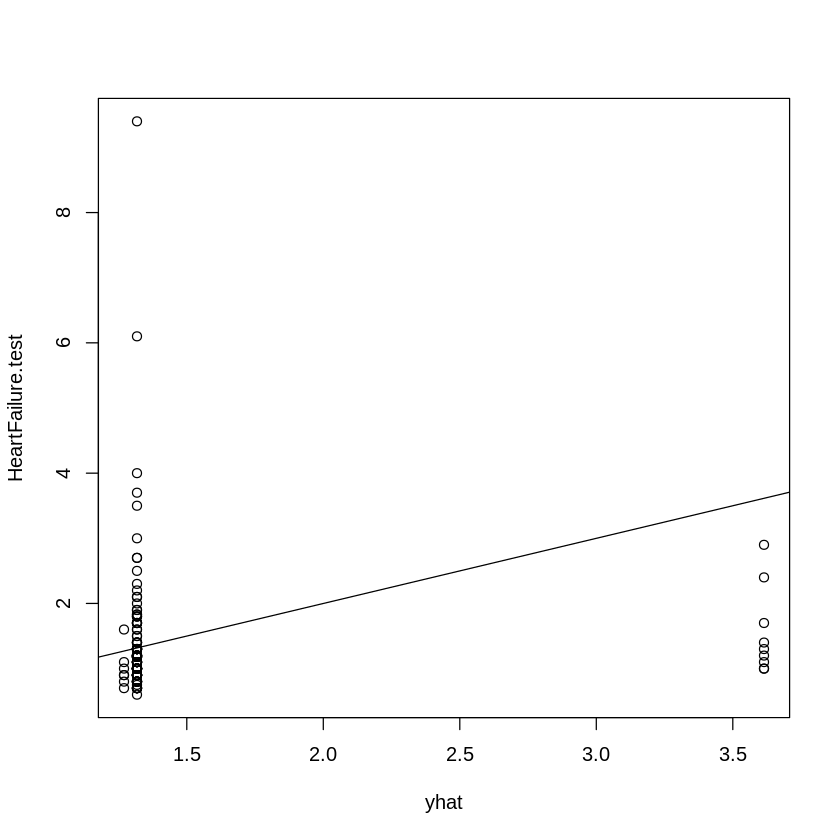

In [ ]:
yhat <- predict(prune.HeartFailure, newdata = HeartFailure[-train, ])
HeartFailure.test <- HeartFailure[-train, "serum_creatinine"]
plot(yhat, HeartFailure.test)
abline(0, 1)
mean((yhat - HeartFailure.test)^2)

For comparison, the unpruned $7$ node tree is also used to make predictions on the test set.

[1] 1.317702

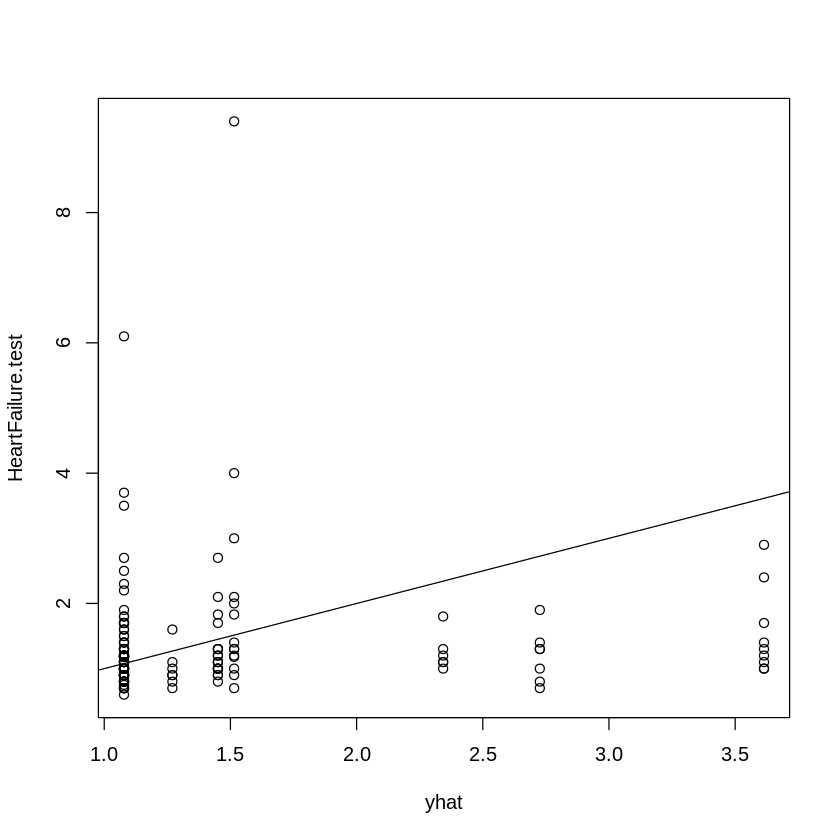

In [ ]:
yhat <- predict(tree.HeartFailure, newdata = HeartFailure[-train, ])
HeartFailure.test <- HeartFailure[-train, "serum_creatinine"]
plot(yhat, HeartFailure.test)
abline(0, 1)
mean((yhat - HeartFailure.test)^2)

The pruned $2$-node tree achieved an MSE of $1.168$ on the test set, outperforming the unpruned $7$-node tree which had an MSE of $1.318$, confirming that simplifying the tree did improve prediction accuracy. The square root of the MSE is approximately $1.081$, meaning the pruned tree predicts `serum_creatinine` within about 1.081 units on average.

### Bagging and Random Forests

Having explored classification and regression trees, we now turn to more advanced methods, `bagging` and `random forests`, which improve upon single trees by combining many trees together to produce more accurate and stable predictions.



In [ ]:
urlPackage <- "https://cran.r-project.org/src/contrib/Archive/randomForest/randomForest_4.7-1.tar.gz"

install.packages(urlPackage, repos=NULL, type="source")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message in install.packages(urlPackage, repos = NULL, type = "source"):
“installation of package ‘/tmp/RtmpLnjyyX/downloaded_packages/randomForest_4.7-1.tar.gz’ had non-zero exit status”


In [ ]:
install.packages("randomForest")
library(randomForest)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.



#### Bagging

Bagging was applied to predict `serum_creatinine` using $500$ trees and all $10$ available predictors at each split. The model explains only $-15.11%$ of the variance, which reflects the difficulty of predicting `serum_creatinine` from the available patient characteristics.

In [ ]:
set.seed(1)
bag.HeartFailure <- randomForest(serum_creatinine~ .-Death-DEATH_EVENT-time, data = HeartFailure,
    subset = train, mtry = 10, importance = TRUE)
bag.HeartFailure


Call:
 randomForest(formula = serum_creatinine ~ . - Death - DEATH_EVENT -      time, data = HeartFailure, mtry = 10, importance = TRUE,      subset = train) 
               Type of random forest: regression
                     Number of trees: 500
No. of variables tried at each split: 10

          Mean of squared residuals: 1.400604
                    % Var explained: -15.11

On the test set, the bagged model achieved an MSE of $1.099$, which is an improvement over the pruned regression tree's MSE of $1.168$.

[1] 1.099447

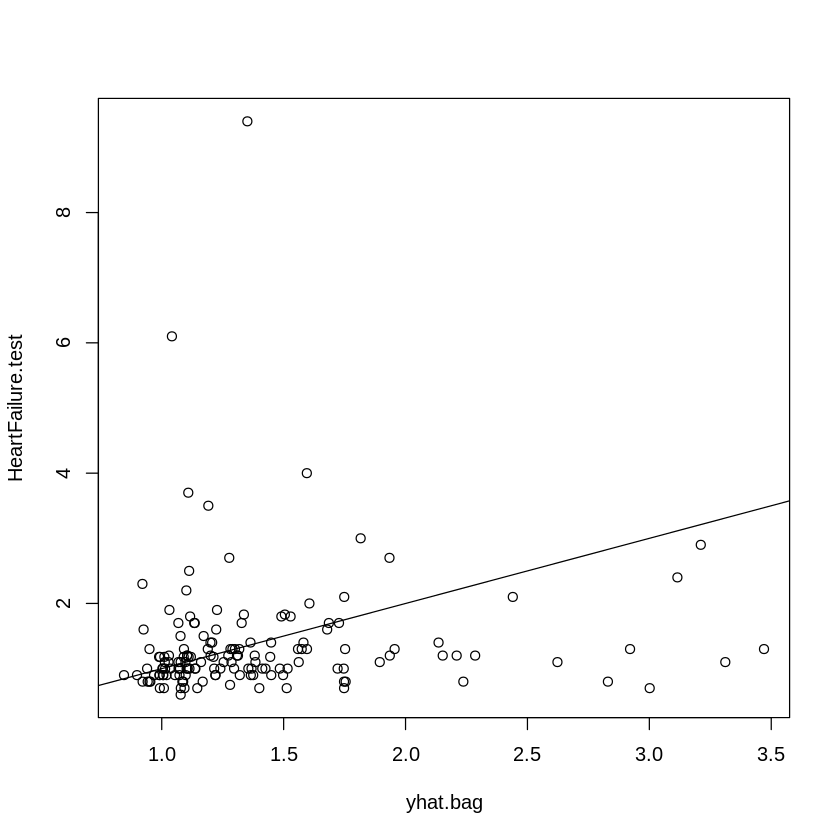

In [ ]:
yhat.bag <- predict(bag.HeartFailure, newdata = HeartFailure[-train, ])
plot(yhat.bag, HeartFailure.test)
abline(0, 1)
mean((yhat.bag - HeartFailure.test)^2)

Reducing the number of trees to $25$ further improved the MSE to $1.056$, demonstrating that a smaller forest is sufficient for this dataset and that additional trees may not actually meaningfully improve predictions.

In [ ]:
bag.HeartFailure <- randomForest(serum_creatinine ~ .-Death-DEATH_EVENT-time, data =HeartFailure,
    subset = train, mtry = 10, ntree = 25)
yhat.bag <- predict(bag.HeartFailure, newdata = HeartFailure[-train, ])
mean((yhat.bag - HeartFailure.test)^2)

[1] 1.056047

##### Random Forest

A random forest was then fitted using mtry = $6$, meaning only 6 randomly selected predictors were considered at each split to predict `serum_creatinine `in the Heart Failure dataset.

In [ ]:
set.seed(1)
rf.HeartFailure <- randomForest(serum_creatinine~ .-Death-DEATH_EVENT-time, data = HeartFailure,
    subset = train, mtry = 6, importance = TRUE)
yhat.rf <- predict(rf.HeartFailure, newdata = HeartFailure[-train, ])
mean((yhat.rf - HeartFailure.test)^2)

[1] 1.068456

The test set MSE is $1.068$; this indicates that random forests did not yield an improvement over bagging in this case.

Using the `importance()` function, the importance of each variable can be assessed. Two measures of variable importance are reported. The first is based upon the mean decrease of accuracy in predictions on the out of bag samples when a given variable is permuted. The second is a measure of the total decrease in node impurity that results from splits over that variable, averaged over all trees. In the case of regression trees, the node impurity is measured by the training RSS.

In [ ]:
importance(rf.HeartFailure)

,%IncMSE,IncNodePurity
age,2.578577,12.270403
anaemia,-2.654289,1.792779
creatinine_phosphokinase,7.733925,23.082162
diabetes,2.061635,1.887763
ejection_fraction,8.985363,59.243150
high_blood_pressure,-1.794210,2.448989
platelets,1.026065,23.693030
serum_sodium,4.598039,28.603551
sex,-1.353853,1.114009
smoking,-1.549058,1.028451


The importance table reveals that `ejection_fraction` is by far the most important variable with a %IncMSE of $8.985$ and IncNodePurity of $59.243$, followed by `serum_sodium` and `creatinine_phosphokinase`. Variables such as `anaemia`, `high_blood_pressure`, `sex`, and `smoking` show very low or even negative importance scores.

This is notably different from the single regression tree, where `platelets` was the root split and the strongest predictor. In a random forest however, importance is measured consistently across $500$ trees where only a random subset of variables is considered at each split, meaning `platelets` does not get the opportunity to dominate every tree as it did in the single tree model.


Plots of these importance measures are produced using the `varImpPlot()` function for visualization.

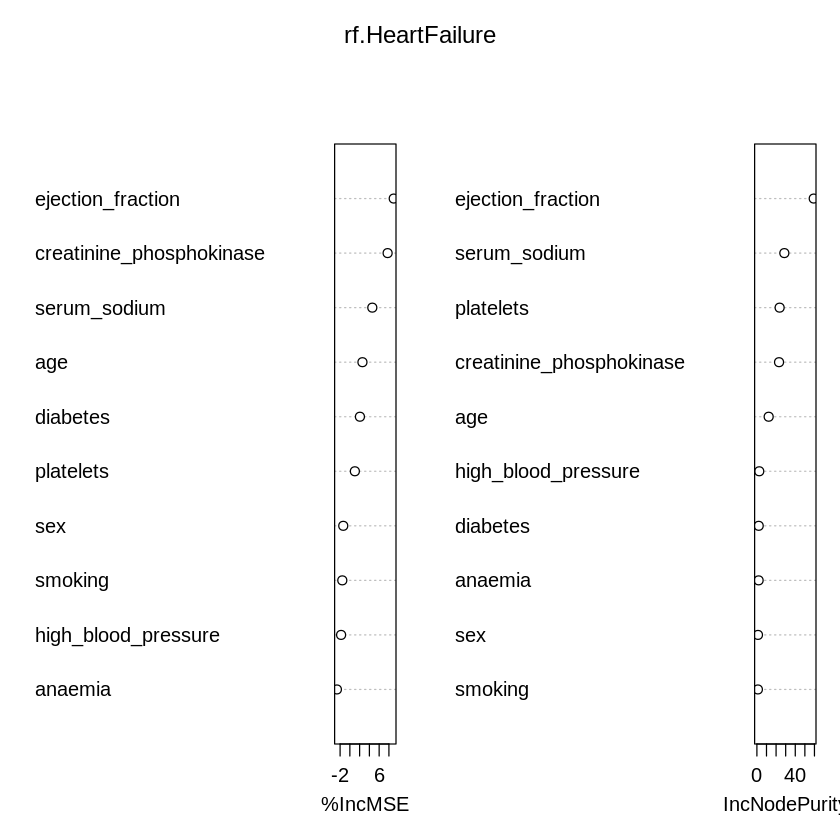

In [ ]:
varImpPlot(rf.HeartFailure)

## Boosting

Here the `gbm` package is used, and within it the `gbm()` function, to fit boosted regression trees to the `HeartFailure` data set to predict `serum_creatinine`. The argument `n.trees = 5000` indicates that $5000$ trees will be produced, and the option `interaction.depth = 4` limits the depth of each tree.

In [ ]:
install.packages('gbm')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(gbm)
set.seed(1)
boost.HeartFailure <- gbm(serum_creatinine~ .-Death-DEATH_EVENT-time, data = HeartFailure[train, ],
    distribution = "gaussian", n.trees = 5000,
    interaction.depth = 4)

Loaded gbm 2.2.3

This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3



The function `summary()` will generate a relative influence plot and print the statistics of relative influence.

In the summary of the boosted model we see that `platelets` is the most influential variable with a relative influence of $26.58$, followed by `ejection_fraction` with $23.12$ and `creatinine_phosphokinase` with $18.89$.

This is more consistent with the single regression tree, where platelets was also identified as the root split and strongest predictor. `Age` and `serum_sodium `follow with moderate influence, while `anaemia`, `high_blood_pressure`, `diabetes`, and `smoking` contribute very little, with `smoking` being the least influential variable at just $0.57$.

The bar plot visually confirms this pattern.

,var,rel.inf
,<chr>,<dbl>
platelets,platelets,26.5789469
ejection_fraction,ejection_fraction,23.1196590
creatinine_phosphokinase,creatinine_phosphokinase,18.8935861
age,age,11.9166914
serum_sodium,serum_sodium,8.7097069
sex,sex,4.2667578
anaemia,anaemia,2.3140395
high_blood_pressure,high_blood_pressure,1.8593425
diabetes,diabetes,1.7676366


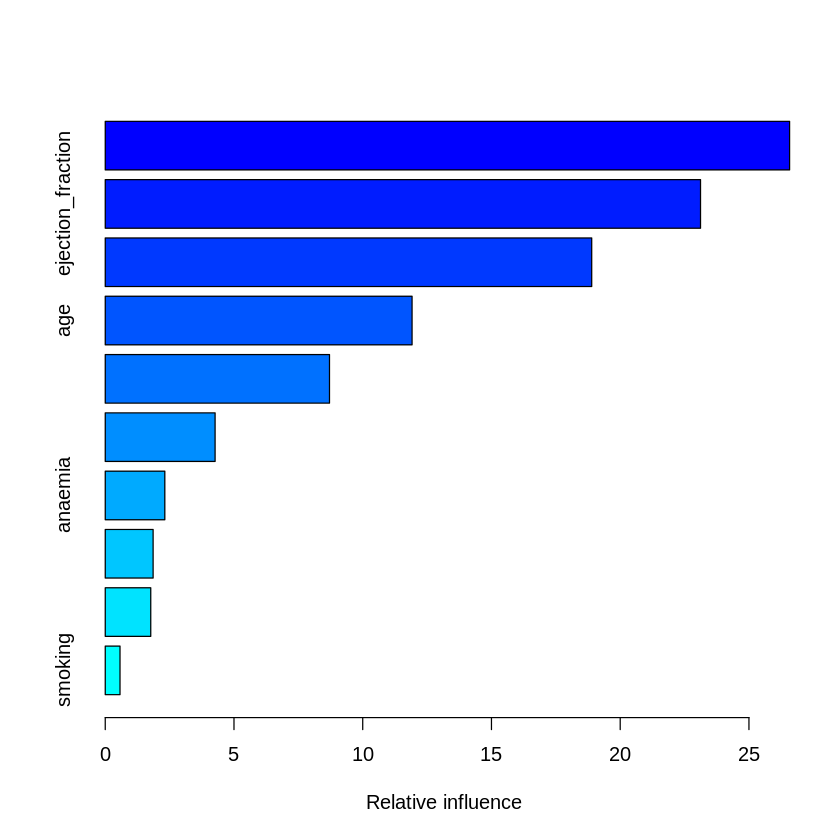

In [ ]:
summary(boost.HeartFailure)

*Partial dependence plots* are produced for the two most important variables. These plots illustrate the effect of the selected variables on the response after *integrating* out the other variables.

 `Serum_creatinine` is highest when `platelet` counts are low, then drops and levels off as `platelets` increase. This may mean that only patients with unusually low platelets tend to have worse kidney function.

For `ejection_fraction`, the relationship is much messier, with `serum_creatinine `bouncing around at lower values before jumping up around $50$ and then flattening out.

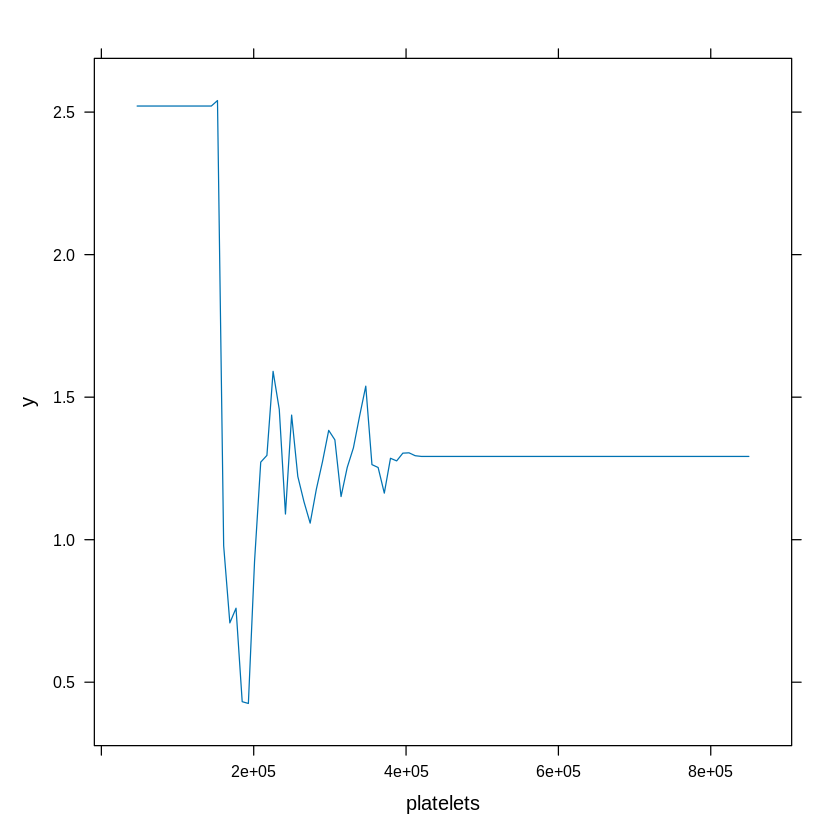

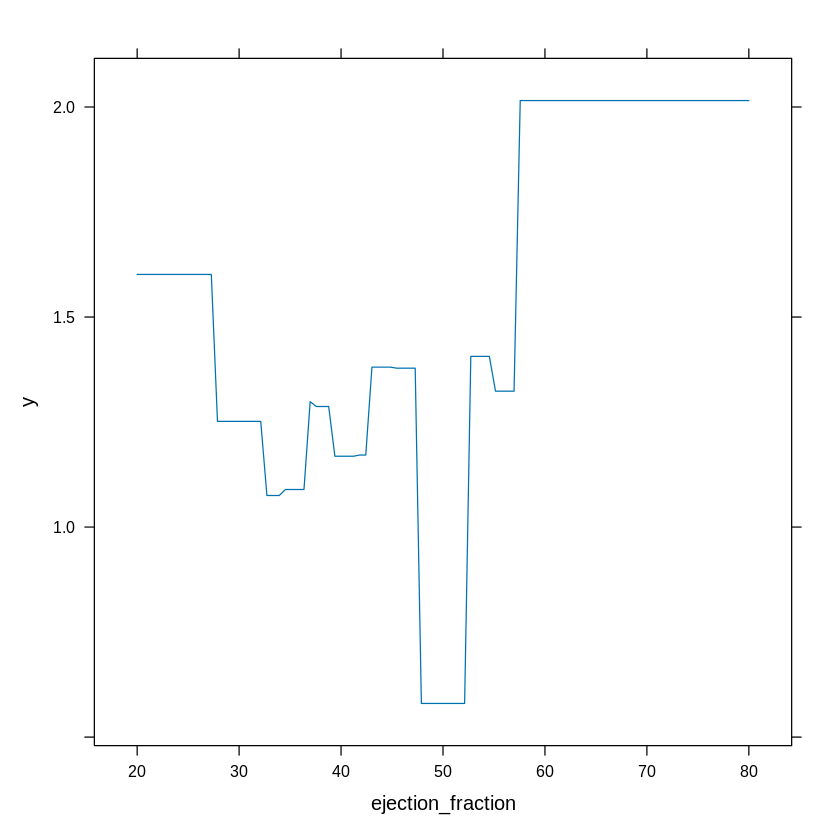

In [ ]:
plot(boost.HeartFailure, i = "platelets")
plot(boost.HeartFailure, i = "ejection_fraction")

The boosted model is used to predict `serum_creatinine` on the test set, achieving an MSE of $1.467$. This is actually worse than both bagging ($1.056$) and the random forest ($1.068$), meaning that boosting may not improve performance for this particular dataset.

In [ ]:
yhat.boost <- predict(boost.HeartFailure,
    newdata = HeartFailure[-train, ], n.trees = 5000)
mean((yhat.boost - HeartFailure.test)^2)

[1] 1.467423

Boosting is also performed with a different value of the shrinkage parameter $\lambda$. The default value is $0.001$, but this is easily modified.
Here $\lambda=0.2$ is used instead. However, this actually increased the MSE slightly to $1.48$.

In [ ]:
boost.HeartFailure <- gbm(serum_creatinine~ .-Death-DEATH_EVENT-time, data = HeartFailure[train, ],
    distribution = "gaussian", n.trees = 5000,
    interaction.depth = 4, shrinkage = 0.2, verbose = F)
yhat.boost <- predict(boost.HeartFailure,
    newdata = HeartFailure[-train, ], n.trees = 5000)
mean((yhat.boost - HeartFailure.test)^2)

[1] 1.485306

## Bayesian Additive Regression Trees


In this section,  the `BART` package is used, and within it the `gbart()` function, to fit a Bayesian additive regression tree model to the Heart Failure data set to predict `serum_creatinine`.

 Unlike bagging and boosting, BART uses Bayesian inference to build $200$ trees while also accounting for uncertainty in the predictions, making it a more statistically rigorous method.

In [ ]:
install.packages('BART')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



To run the `gbart()` function, matrices of predictors must first be created for the training and test data. We run BART with default settings. Notably, we had to remove` Death`, `Death_event`, and `time`.

In [ ]:
library(BART)
x <- HeartFailure[, !(names(HeartFailure) %in% c("serum_creatinine", "DEATH_EVENT", "time", "Death"))]
y <- HeartFailure[, "serum_creatinine"]
xtrain <- x[train, ]
ytrain <- y[train]
xtest <- x[-train, ]
ytest <- y[-train]
set.seed(1)
bartfit <- gbart(xtrain, ytrain, x.test = xtest)

*****Calling gbart: type=1
*****Data:
data:n,p,np: 149, 10, 150
y1,yn: -0.722282, -0.422282
x1,x[n*p]: 53.000000, 0.000000
xp1,xp[np*p]: 55.000000, 1.000000
*****Number of Trees: 200
*****Number of Cut Points: 40 ... 1
*****burn,nd,thin: 100,1000,1
*****Prior:beta,alpha,tau,nu,lambda,offset: 2,0.95,0.15026,3,0.242772,1.42228
*****sigma: 1.116386
*****w (weights): 1.000000 ... 1.000000
*****Dirichlet:sparse,theta,omega,a,b,rho,augment: 0,0,1,0.5,1,10,0
*****printevery: 100

MCMC
done 0 (out of 1100)
done 100 (out of 1100)
done 200 (out of 1100)
done 300 (out of 1100)
done 400 (out of 1100)
done 500 (out of 1100)
done 600 (out of 1100)
done 700 (out of 1100)
done 800 (out of 1100)
done 900 (out of 1100)
done 1000 (out of 1100)
time: 3s
trcnt,tecnt: 1000,1000


The BART model achieved a test set MSE of $0.943$, the lowest of all methods tested in this analysis, outperforming bagging, random forests, and boosting.

In [ ]:
yhat.bart <- bartfit$yhat.test.mean
mean((ytest - yhat.bart)^2)

[1] 0.9432627

Next, how many times each variable appeared in the collection of trees is analyzed. Surprisingly, `platelets` and `ejection_fraction`, which dominated earlier methods, appear least frequently in the BART trees, while binary variables like `high_blood_pressure` and `anaemia` are used most often.

This is because BART captures the strong predictors efficiently in just a few trees, then relies more heavily on the weaker binary variables to extract any remaining signal.

In [ ]:
ord <- order(bartfit$varcount.mean, decreasing = T)
bartfit$varcount.mean[ord]

high_blood_pressure                  anaemia                      sex 
                  27.123                   26.557                   25.961 
                diabetes                  smoking                      age 
                  25.627                   25.376                   22.385 
            serum_sodium        ejection_fraction creatinine_phosphokinase 
                  21.226                   20.232                   13.169 
               platelets 
                  12.629

# Results

##### Previous Analyses on the Data Set

Previous analyses using logistic regression, LDA, QDA, and Naive Bayes achieved classification accuracies ranging from $78.8\%$ to $89.9\%$, with QDA and Naive Bayes performing best at $89.9\%$.

##### Classification Tree Results - Predicting Mortality Outcomes

In [ ]:
kable(classification_results)



|Method                                  |Accuracy |Key_Variables                                                                         |
|:---------------------------------------|:--------|:-------------------------------------------------------------------------------------|
|Unpruned Classification Tree (18 nodes) |65.7%    |serum_creatinine, ejection_fraction, serum_sodium, age, creatinine_phosphokinase      |
|Pruned Classification Tree (5 nodes)    |73.3%    |ejection_fraction, serum_creatinine, age                                              |
|Larger Pruned Tree (14 nodes)           |68.7%    |ejection_fraction, serum_creatinine, age, anaemia, diabetes, creatinine_phosphokinase |

The unpruned classification tree was generated for all the $299$ patients without train/test split and the training accuracy was $82.3\%$ However, the model was tested using the same data that it was trained on. On the whole dataset,`serum_creatinine` was the root split and strongest predictor, with patients above $1.815$ having a $72.9\%$ risk of mortality, and $100.0\%$ of patients with levels over $2.05$ dying. Furthermore, when `ejection_fraction `fell below $22.5$, the death rate was $100\%$. Interestingly, good kidney function (low `serum_creatinine`) seems to compensate for poor heart function (low `ejection_fraction`).

Later, `age` worked as a supplementary filter, with patients over $79.5$ having a $69\%$ predicted death rate, even when `ejection_fraction` was less dangerous.`Serum sodium` levels above $141.5$ were related with a lower mortality rate of $16.7\%$. Notably, `anaemia`, `diabetes`, `high_blood_pressure`, `platelets`,`sex`, and `smoking` all contributed no splits, which is consistent with previous findings from the Heart Failure dataset.


Using an appropriate $150/149$ train/test split resulted in a decline in test accuracy to $65.7\%$. Interestingly, the root split was `ejection_fraction` rather than `serum_creatinine`. Thus, the importance of each variable may depend on sample.

Pruning to $5$ nodes improved performance to $73.3\%$, leaving only `ejection_fraction`,`serum_creatinine`, and `age`. A larger $14$-node tree degraded outcomes by $68.7\%$, confirming $5$ nodes as optimal.

###### Regresssion Tree Results - Predicting Serum Creatinine Levels

In [ ]:
kable(regression_results)



|Method                             |   MSE|Key_Variables                                                             |
|:----------------------------------|-----:|:-------------------------------------------------------------------------|
|Unpruned Regression Tree (7 nodes) | 1.318|platelets, creatinine_phosphokinase, serum_sodium, ejection_fraction, age |
|Pruned Regression Tree (2 nodes)   | 1.168|platelets, creatinine_phosphokinase                                       |
|Bagging (500 trees)                | 1.099|All 10 variables                                                          |
|Bagging (25 trees)                 | 1.056|All 10 variables                                                          |
|Random Forest                      | 1.068|ejection_fraction, serum_sodium, creatinine_phosphokinase                 |
|Boosting (λ = 0.001)               | 1.464|platelets, ejection_fraction, creatinine_phosphokinase                    |
|Boosting (λ = 0.2)                 | 

The regression tree had an MSE of $1.318$ and `platelets`, `creatinine_phosphokinase`, `serum_sodium`, `ejection_fraction` and `age`before being pruned. The root split was on `platelets`. This was then followed by the splits in `creatinine_phosphokinase` for those with lower `platelet`levels, and `serum sodium` for those with greater `platelet`levels.

However, when cross validation was performed, it was revealed that the error was the lowest at only $1$ node. A tree with $2$ terminal node was selected in order to produce a meaningful tree structure for analysis. Pruning to $2$ nodes improved results with an MSE of $1.168$. Only the `platelets`split, and the `creatinine_phosphokinase`split for patients with lower `platelet` levels remained.

Bagging was used to predict `serum_creatinine` using $500$ trees and all available predictors at each split, producing an MSE of $1.099$. Interestingly, using only $25$ trees actually performed better with an MSE of $1.056$. Random forest achieved a similar MSE of $1.068$ using only $6$ randomly selected predictors at each split.

The importance table shows that `ejection_fraction` was the strongest predictor, followed by `serum_sodium` and `creatinine_phosphokinase`. While variables such as `anaemia`, `high_blood_pressure`, `sex`, and `smoking` showed low or even negative importance scores. This was a stark contrast to the single regression tree, where `platelets` was the root split and the strongest predictor.

Boosting produced $5000$ trees to predict `serum_creatinine`, but performed the worst of the advanced methods, with MSEs of $1.464$ and $1.486$ for shrinkage values of $0.001$ and $0.2$ respectively. The summary of the boosted model revealed that `platelets` is the most influential variable with a relative influence of $26.58$, followed closely by `ejection_fraction` at $23.12$ and `creatinine_phosphokinase` at $18.89$. This is more consistent with the single regression tree results.Partial dependence plots were used to illustrate the marginal effect of the two most important variables, `platelets` and `ejection_ fraction`. While it seems that patients with unusually low `platelets` tend to have worse kidney function, it was much more difficult to interpret `ejection_fraction's` irratic relationship with `serum_creatinine`.

 BART achieved the lowest MSE of $0.943$, outperforming all other methods. It is a more statistically rigorous method than bagging and boosting. Surprisingly, `platelets` and `ejection_fraction`, which dominated earlier methods, appear least frequently in the BART trees, while binary variables like `high_blood_pressure` and `anaemia` are used most often. This is because BART figures out the strong predictors quickly and then focuses on the weaker variables to extract any extra information from them.

# Discussion

##### Classification Tree Results - Predicting Mortality Outcomes

The results of this study show both the strengths and limitations of tree-based methods for predicting heart failure outcomes. For the classification task, the pruned 5-node tree achieved a test accuracy of $73.3\%$, which, while an improvement over the unpruned tree, falls short of the $89.9\%$ achieved by QDA and Naive Bayes in previous analyses.

This suggests that for binary classification of mortality, more flexible probabilistic methods may outperform single decision trees on this dataset. However, it is easier to find meaning in the tree based methods, for example, the 5-node tree shows that `ejection_fraction`, `serum_creatinine`, and `age` are the three most important predictors.

###### Regresssion Tree Results - Predicting Serum Creatinine Levels

For the regression tree, BART had the smallest MSE of $0.943$, with better results than bagging, random forests, and boosting. Interestingly, boosting performed the worst among the advanced methods.

Unlike bagging and random forests which build trees independently, boosting builds trees one at a time where each new tree tries to fix the mistakes of the previous one. This approach may have overcorrected and accumulated errors for this dataset.

Overall, the high MSE across all methods shows how difficult it is to predict `serum_creatinine` from the variables in Heart Failure dataset. This may be due to outliers or the small sample size of 299 patients or both.

#####

# Conclusion

`Ejection_fraction` and `serum_creatinine` seem to be the most important clinical predictors, which makes sense with the current research. `Age` served as filter after these variables, especially at extremes. However, other lifestyle and demographic variables such as `smoking`, `sex`, and `diabetes` contributed little.

For mortality classification, tree-based methods did not surpass the $89.9\%$ accuracy achieved by QDA and Naive Bayes in previous analyses, which could mean that probabilistic methods perform better on this dataset. However, the pruned classification tree offers a clinically useful and interpretable alternative, as it mapped out how combinations of `ejection_fraction`, `serum_creatinine`, and `age` interact to determine mortality risk.

For `serum creatinine` prediction, BART performed best but even the strongest method produced an MSE of $0.943$. Across all regression methods, `platelets` and `ejection_fraction` seemed to be the most important predictors. Clinical measurements were more likely to be useful to the model than binary demographic variables. Interestingly, BART tried to extract information from factors like `high_blood_pressure` and `anaemia`,that were not useful to other methods.

Larger datasets and additional clinical measurements could help create a better model in the future. Additionally, the analysis of both probabilistic methods like QDA, and decision trees, could help create models that are both accurate and easy for clinicians to understand and act on.

# Appendix

In [ ]:
variable_table <- data.frame(
  Variable = c("age",
               "anaemia",
               "creatinine_phosphokinase",
               "diabetes",
               "ejection_fraction",
               "high_blood_pressure",
               "platelets",
               "sex",
               "serum_creatinine",
               "serum_sodium",
               "smoking",
               "time",
               "death_event"),

  Description = c("Age of the patient (years)",
                  "Decrease of red blood cells or hemoglobin (boolean)",
                  "Level of CPK enzyme in blood (mcg/L)",
                  "Presence of diabetes (boolean)",
                  "Percentage of blood leaving heart at each contraction",
                  "Presence of hypertension (boolean)",
                  "Platelets in blood (kiloplatelets/mL)",
                  "Sex (binary: 0 = female, 1 = male)",
                  "Serum creatinine level (mg/dL)",
                  "Serum sodium level (mEq/L)",
                  "Smoking status (boolean)",
                  "Follow-up period (days)",
                  "Death during follow-up (boolean)")
)

##### Classification Table

In [ ]:
classification_results <- data.frame(
  Method = c("Unpruned Classification Tree (18 nodes)",
             "Pruned Classification Tree (5 nodes)",
             "Larger Pruned Tree (14 nodes)"),
  Training_Accuracy = c("82.3%", "—", "—"),
  Test_Accuracy = c("65.7%", "73.3%", "68.7%"),
  Key_Variables = c("serum_creatinine, ejection_fraction, serum_sodium, age, creatinine_phosphokinase",
                    "ejection_fraction, serum_creatinine, age",
                    "ejection_fraction, serum_creatinine, age, anaemia, diabetes, creatinine_phosphokinase")
)
library(knitr)
kable(classification_results)



|Method                                  |Training_Accuracy |Test_Accuracy |Key_Variables                                                                         |
|:---------------------------------------|:-----------------|:-------------|:-------------------------------------------------------------------------------------|
|Unpruned Classification Tree (18 nodes) |82.3%             |65.7%         |serum_creatinine, ejection_fraction, serum_sodium, age, creatinine_phosphokinase      |
|Pruned Classification Tree (5 nodes)    |—                 |73.3%         |ejection_fraction, serum_creatinine, age                                              |
|Larger Pruned Tree (14 nodes)           |—                 |68.7%         |ejection_fraction, serum_creatinine, age, anaemia, diabetes, creatinine_phosphokinase |

##### Serum Creatinine Table

In [ ]:
regression_results <- data.frame(
  Method = c("Unpruned Regression Tree (7 nodes)",
             "Pruned Regression Tree (2 nodes)",
             "Bagging (500 trees)",
             "Bagging (25 trees)",
             "Random Forest",
             "Boosting (λ = 0.001)",
             "Boosting (λ = 0.2)",
             "BART"),
  MSE = c(1.318, 1.168, 1.099, 1.056, 1.068, 1.464, 1.486, 0.943),
  Key_Variables = c("platelets, creatinine_phosphokinase, serum_sodium, ejection_fraction, age",
                    "platelets, creatinine_phosphokinase",
                    "All 10 variables",
                    "All 10 variables",
                    "ejection_fraction, serum_sodium, creatinine_phosphokinase",
                    "platelets, ejection_fraction, creatinine_phosphokinase",
                    "platelets, ejection_fraction, creatinine_phosphokinase",
                    "high_blood_pressure, anaemia, sex")
)
kable(regression_results)



|Method                             |   MSE|Key_Variables                                                             |
|:----------------------------------|-----:|:-------------------------------------------------------------------------|
|Unpruned Regression Tree (7 nodes) | 1.318|platelets, creatinine_phosphokinase, serum_sodium, ejection_fraction, age |
|Pruned Regression Tree (2 nodes)   | 1.168|platelets, creatinine_phosphokinase                                       |
|Bagging (500 trees)                | 1.099|All 10 variables                                                          |
|Bagging (25 trees)                 | 1.056|All 10 variables                                                          |
|Random Forest                      | 1.068|ejection_fraction, serum_sodium, creatinine_phosphokinase                 |
|Boosting (λ = 0.001)               | 1.464|platelets, ejection_fraction, creatinine_phosphokinase                    |
|Boosting (λ = 0.2)                 | 